# Validating STCS against Xenium: per-cell IoU

`Parameter_Tuning.ipynb` picks the search radius **S** and the spatial weight
**lambda** *without any reference*, from spatial connectivity and transcript
consistency alone. This notebook is the independent check on that choice: it measures how
well the reconstructed cell boundaries agree with cells measured by **Xenium on the same
tissue section**, using intersection-over-union.

**Nothing is reconstructed again here.** The parameter sweep already wrote one `.h5ad`
per (crop, S, lambda) containing the bin-to-cell assignment and the bin coordinates, and
that is everything the geometry needs. Run `Parameter_Tuning.ipynb` through its sweep
cell first, then point `RESULTS_PATH` below at the same directory.

### What you need to download

| | where from |
|---|---|
| Visium HD run + H&E image | the Visium HD dataset page (already needed for `Parameter_Tuning.ipynb`) |
| Xenium `cell_boundaries.parquet` | the matched Xenium output bundle |
| Xenium `cells.parquet` | the same bundle, for `segmentation_method` |
| the Xenium-to-H&E registration | the image alignment used to put both modalities in one frame |

The Xenium bundle for the tutorial slide is the post-Xenium human lung cancer section
listed in the README, i.e. the *same physical section* as the Visium HD run. That is what
makes a cell-by-cell comparison meaningful; a different section of the same block would
not work, because the cells themselves differ.

Steps below: paths -> reference polygons -> IoU per run -> average over crops -> heatmap.


## 1. Paths

`RESULTS_PATH` **must** be the same directory `Parameter_Tuning.ipynb` wrote its sweep to.
The filenames there encode the crop rectangle and the parameters
(`crop01_x6300_y12600_w3000_h3000_S2_L0.5.h5ad`), which is how each run is matched back to
the right patch of the reference.


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import sys

# Import STCS from THIS checkout: other copies of STCS_main.py exist on this machine,
# and a relative sys.path.append would let whichever is found first win.
STCS_DIR = os.path.abspath("STCS")
sys.path.insert(0, STCS_DIR)
from STCS_main import STCS

import STCS_main
assert os.path.samefile(os.path.dirname(STCS_main.__file__), STCS_DIR), (
    "A different STCS_main is loaded. Restart the kernel and run from the top.")

# --- the parameter sweep's output directory (same value as in Parameter_Tuning.ipynb) ---
RESULTS_PATH = "/lab01/lc1418/ST/stcs_sweep_stardist"

# --- Xenium cell boundaries, ALREADY REGISTERED into the H&E pixel frame ---
# one row per polygon vertex; see section 2 for how this file is produced
XENIUM_BOUNDARIES = "/home/lc1418/ST/aligned.csv"
XB_ID, XB_X, XB_Y = "cell_id", "x_he_px", "y_he_px"

# --- Xenium per-cell metadata, for segmentation_method ---
XENIUM_CELLS = "/lab01/lc1418/ST/Xenium_Prime_extracted/cells.parquet"

OUT_DIR = os.path.join(RESULTS_PATH, "iou_vs_xenium")
os.makedirs(OUT_DIR, exist_ok=True)

runs = sorted(glob.glob(os.path.join(RESULTS_PATH, "*.h5ad")))
print("sweep runs found:", len(runs))
print("example:", os.path.basename(runs[0]) if runs else "(none - run the sweep first)")


/home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


sweep runs found: 180
example: crop01_x6300_y12600_w3000_h3000_S10_L0.01.h5ad


## 2. The Xenium reference, and its coordinate frame

**This is the step that decides whether the numbers mean anything.**

Xenium publishes `cell_boundaries.parquet` in its own micron coordinate system, while STCS
works in full-resolution pixels of the H&E image. An IoU is only interpretable once both
are in **one** frame, so the Xenium vertices must have the Xenium-to-H&E registration
applied to them:

```python
# one-off, from the raw bundle:
xb = pd.read_parquet("cell_boundaries.parquet")      # cell_id, vertex_x, vertex_y (microns)
xy = np.column_stack([xb.vertex_x, xb.vertex_y, np.ones(len(xb))]) @ A.T   # A = 3x3 affine
xb["x_he_px"], xb["y_he_px"] = xy[:, 0], xy[:, 1]
xb.to_csv("aligned.csv", index=False)
```

`A` is the affine from the image alignment (e.g. the matrix produced by the Xenium Explorer
alignment, or by the registration you ran yourself). We did this once and saved the result,
which is what `XENIUM_BOUNDARIES` points at; if you are starting from the raw bundle, run
the snippet above and point at your own output.

A **rigid offset of about one cell width costs roughly 0.1 of mean IoU** across the board,
so a bad registration looks exactly like a bad method. The assertion below is the cheap
guard: the reference extent must overlap the Visium bins.

### Segmentation categories

Xenium does not segment every cell the same way, and the three ways are not equally
trustworthy. `cells.parquet` records which was used per cell, so IoU is reported broken
down by it as well as pooled:

- **interior stain (18S)** — the bulk of cells
- **boundary stain (ATP1A1+CD45+E-Cadherin)** — membrane-resolved
- **nucleus expansion, 5 um** — a *fallback* where neither stain resolved a boundary; it is
  a fixed disc, not a measured outline, so disagreement here says little about the
  reconstruction


In [2]:
# --- boundary vertices ---
xb = pd.read_csv(XENIUM_BOUNDARIES, usecols=[XB_ID, XB_X, XB_Y])
xb[XB_ID] = xb[XB_ID].astype(str)
print("vertices: %d over %d reference cells" % (len(xb), xb[XB_ID].nunique()))
print("reference extent:  x %.0f .. %.0f    y %.0f .. %.0f"
      % (xb[XB_X].min(), xb[XB_X].max(), xb[XB_Y].min(), xb[XB_Y].max()))

# --- frame check: the crop rectangles must fall inside the reference extent ---
rects = {STCS._parse_run_filename(f)["crop_id"]: STCS._parse_run_filename(f) for f in runs}
for cid in sorted(rects):
    r = rects[cid]
    inside = ((xb[XB_X] >= r["x"]) & (xb[XB_X] <= r["x"] + r["w"]) &
              (xb[XB_Y] >= r["y"]) & (xb[XB_Y] <= r["y"] + r["h"]))
    print("crop %d at (%d, %d): %d reference vertices inside"
          % (cid, r["x"], r["y"], int(inside.sum())))
    assert inside.sum() > 0, "crop %d has no reference cells - check the registration" % cid


vertices: 6952637 over 278328 reference cells
reference extent:  x -2073 .. 26683    y 579 .. 42568
crop 1 at (6300, 12600): 186021 reference vertices inside
crop 2 at (7900, 3900): 181324 reference vertices inside
crop 3 at (11600, 17000): 140172 reference vertices inside
crop 4 at (9300, 12400): 139447 reference vertices inside
crop 5 at (8000, 8900): 139120 reference vertices inside


In [3]:
# --- per-cell segmentation method, shortened for plotting ---
CATMAP = {
    "Segmented by interior stain (18S)": "Interior stain",
    "Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)": "Boundary stain",
    "Segmented by nucleus expansion of 5.0\u00b5m": "Nucleus expansion",
}
xc = pd.read_parquet(XENIUM_CELLS, columns=["cell_id", "segmentation_method"])
xc["cell_id"] = xc["cell_id"].astype(str)
print(xc.segmentation_method.value_counts().to_string())

cat_map = dict(zip(xc.cell_id, xc.segmentation_method.map(CATMAP)))
unmapped = xc.segmentation_method[xc.segmentation_method.map(CATMAP).isna()].unique()
if len(unmapped):
    print("\n[Warn]: unmapped segmentation_method labels, extend CATMAP:", unmapped)


segmentation_method
Segmented by interior stain (18S)                       228200
Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)     43888
Segmented by nucleus expansion of 5.0µm                   6240


## 3. How the IoU is computed

For each saved run, i.e. one crop at one (S, lambda):

**Polygons.** A reconstructed cell is the **convex hull of the bin centres assigned to
it**. A reference cell is the convex hull of its own vertices. Hulls are convex while real
cells are not, so absolute IoU is optimistic, but *identically* so on both sides and for
every setting, which is what matters when the purpose is to rank parameters. Cells with
fewer than 3 bins cannot form a polygon and are dropped.

**Quality control.** Reconstructed cells first pass the same QC as the published pipeline,
`filter_genes(min_counts=3)` then `filter_cells(min_genes=50)`, so the comparison covers
the cells that would actually be used downstream rather than every fragment the assignment
produced. Pass `apply_qc=False` to see the unfiltered numbers.

**Matching.** Mutual best-IoU, with **no threshold**: cell A pairs with B only if B is A's
best overlap *and* A is B's. Each cell therefore matches at most one partner. The mutual
condition is deliberate — a one-sided nearest-match lets one large reference cell absorb
many fragments and quietly rewards over-segmentation.

$$\mathrm{IoU} = \frac{\mathrm{area}(A \cap B)}{\mathrm{area}(A \cup B)}$$

**Scoring.** Mean and median IoU over matched pairs, plus detection precision (matched /
reconstructed), recall (matched / reference) and their F1, pooled and per category.

The call below reads every `.h5ad` back from disk, so it is the slow cell — a few minutes
for a full grid. It writes the per-pair IoUs next to the runs, so re-running the analysis
later costs nothing.

**One frame, again.** The sweep's `.h5ad` files may store `obsm['spatial']` either in
global image pixels or in coordinates local to the crop (0..w, 0..h) — which depends on how
the crop was prepared. The function detects which and shifts local coordinates onto the
global frame using the rectangle in the filename, so you do not have to care; pass
`verbose=True` to see the frame it chose and the resulting extent per run. Always glance at
that line on a first run: if a crop reports `global` with an extent of 0..3000, the shift
was skipped and every IoU will be zero.


In [4]:
iou_run_summary = STCS.compute_iou_vs_reference_for_saved_runs(
    results_path=RESULTS_PATH,
    reference_vertices=xb,              # the registered vertex table from section 2
    reference_categories=cat_map,       # per-cell segmentation_method
    ref_id_col=XB_ID, ref_x_col=XB_X, ref_y_col=XB_Y,
    apply_qc=True,                      # same QC as the published pipeline
    verbose=True,                       # print the detected coordinate frame per run
)

print(iou_run_summary.shape)
iou_run_summary.head()


[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.01.h5ad  frame=crop-local  bins x 6300..9300  y 12600..15600
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.01.h5ad  matched 2521/7559  mean IoU 0.2530
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.05.h5ad  frame=crop-local  bins x 6300..9300  y 12600..15600
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.05.h5ad  matched 4400/7559  mean IoU 0.3713
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.1.h5ad  frame=crop-local  bins x 6300..9300  y 12600..15600
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.1.h5ad  matched 4892/7559  mean IoU 0.4272
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.5.h5ad  frame=crop-local  bins x 6300..9300  y 12600..15600
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.5.h5ad  matched 5106/7559  mean IoU 0.4811
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.h5ad  frame=crop-local  bins x 6300..9300  y 12600..15600
[Log]: crop01_x6300_y12600_w3000_h3000_S10_L0.h5ad  matched 1889/7559  mean IoU 0.2042
[Log]: crop01_x6300_y1260

,file,crop_id,x,y,w,h,S,L,category,n_recon,n_ref,n_matched,mean_iou,median_iou,det_precision,det_recall,det_f1
0,/lab01/lc1418/ST/stcs_sweep_stardist/crop01_x6...,1,6300,12600,3000,3000,10.0,0.01,ALL,3942,7559,2521,0.252993,0.241985,0.639523,0.333510,0.438397
1,/lab01/lc1418/ST/stcs_sweep_stardist/crop01_x6...,1,6300,12600,3000,3000,10.0,0.01,Boundary stain,3942,2879,1095,0.273356,0.263332,0.277778,0.380340,0.321067
2,/lab01/lc1418/ST/stcs_sweep_stardist/crop01_x6...,1,6300,12600,3000,3000,10.0,0.01,Interior stain,3942,4567,1393,0.238960,0.224106,0.353374,0.305014,0.327418
3,/lab01/lc1418/ST/stcs_sweep_stardist/crop01_x6...,1,6300,12600,3000,3000,10.0,0.01,Nucleus expansion,3942,113,33,0.169670,0.168343,0.008371,0.292035,0.016276
4,/lab01/lc1418/ST/stcs_sweep_stardist/crop01_x6...,1,6300,12600,3000,3000,10.0,0.05,ALL,4982,7559,4400,0.371296,0.361612,0.883179,0.582088,0.701698


In [5]:
# one row per (crop, S, lambda, category); per-pair IoUs are saved alongside
iou_run_summary.to_csv(os.path.join(OUT_DIR, "iou_summary_per_run.csv"), index=False)
iou_run_summary[iou_run_summary.category == "ALL"].pivot_table(
    index=["S", "L"], columns="crop_id", values="mean_iou").round(3)


crop_id        1      2      3      4      5
S    L                                      
1.0  0.00  0.516  0.492  0.516  0.520  0.502
     0.01  0.516  0.492  0.516  0.520  0.502
     0.05  0.516  0.492  0.516  0.520  0.502
     0.10  0.516  0.492  0.516  0.520  0.502
     0.50  0.516  0.492  0.516  0.520  0.502
     1.00  0.516  0.492  0.516  0.520  0.502
2.0  0.00  0.524  0.514  0.552  0.552  0.527
     0.01  0.524  0.515  0.553  0.552  0.528
     0.05  0.526  0.520  0.557  0.556  0.532
     0.10  0.534  0.527  0.563  0.562  0.535
     0.50  0.549  0.542  0.573  0.575  0.551
     1.00  0.551  0.544  0.575  0.576  0.552
3.0  0.00  0.400  0.402  0.436  0.435  0.400
     0.01  0.407  0.409  0.444  0.443  0.407
     0.05  0.439  0.442  0.474  0.474  0.437
     0.10  0.471  0.472  0.502  0.502  0.465
     0.50  0.514  0.512  0.538  0.536  0.503
     1.00  0.517  0.516  0.540  0.538  0.506
4.0  0.00  0.323  0.328  0.359  0.360  0.321
     0.01  0.336  0.342  0.372  0.372  0.334
     0.05  0.399  0.401  0.427  0.429  0.385
     0.10  0.446  0.444  0.469  0.469  0.425
     0.50  0.498  0.494  0.514  0.512  0.472
     1.00  0.501  0.498  0.517  0.514  0.475
5.0  0.00  0.271  0.275  0.296  0.300  0.265
     0.01  0.290  0.294  0.318  0.320  0.282
     0.05  0.379  0.379  0.396  0.401  0.357
     0.10  0.435  0.430  0.446  0.451  0.402
     0.50  0.488  0.483  0.496  0.495  0.451
     1.00  0.492  0.486  0.498  0.498  0.453
10.0 0.00  0.204  0.203  0.228  0.236  0.192
     0.01  0.253  0.257  0.274  0.280  0.236
     0.05  0.371  0.371  0.381  0.385  0.342
     0.10  0.427  0.424  0.431  0.436  0.388
     0.50  0.481  0.476  0.477  0.481  0.435
     1.00  0.485  0.480  0.480  0.484  0.437

## 4. Average over the crops

Every (S, lambda) was run on every crop, so the per-run values are averaged across crops to
give one number per grid cell. Spread between crops is the natural yardstick for whether a
difference between two settings is real — check it before reading anything into the third
decimal place.


In [6]:
CATS = ["ALL", "Boundary stain", "Interior stain", "Nucleus expansion"]

def iou_grid(summary, category="ALL", value="mean_iou"):
    """Mean over crops of `value`, as an S x lambda table."""
    sub = summary[summary.category == category]
    return sub.groupby(["S", "L"])[value].mean().unstack()

print("mean IoU, pooled over categories:")
display(iou_grid(iou_run_summary, "ALL").round(3))

spread = (iou_run_summary[iou_run_summary.category == "ALL"]
          .groupby(["S", "L"]).mean_iou.std())
print("\nbetween-crop SD of mean IoU: median %.4f, max %.4f"
      % (spread.median(), spread.max()))


mean IoU, pooled over categories:


L,0.00,0.01,0.05,0.10,0.50,1.00
S,,,,,,
1.0,0.509,0.509,0.509,0.509,0.509,0.509
2.0,0.534,0.534,0.538,0.544,0.558,0.560
3.0,0.415,0.422,0.453,0.482,0.521,0.524
4.0,0.338,0.351,0.408,0.451,0.498,0.501
5.0,0.281,0.301,0.382,0.433,0.482,0.486
10.0,0.213,0.260,0.370,0.421,0.470,0.473



between-crop SD of mean IoU: median 0.0172, max 0.0201


## 5. The heatmap

One panel per Xenium segmentation category. **Solid yellow** marks the single highest
value; **dashed white** marks every cell equal to it and highest value.


[Log]: saved /lab01/lc1418/ST/stcs_sweep_stardist/iou_vs_xenium/IOU_BY_CATEGORY_WITH_TIES_2dp.png


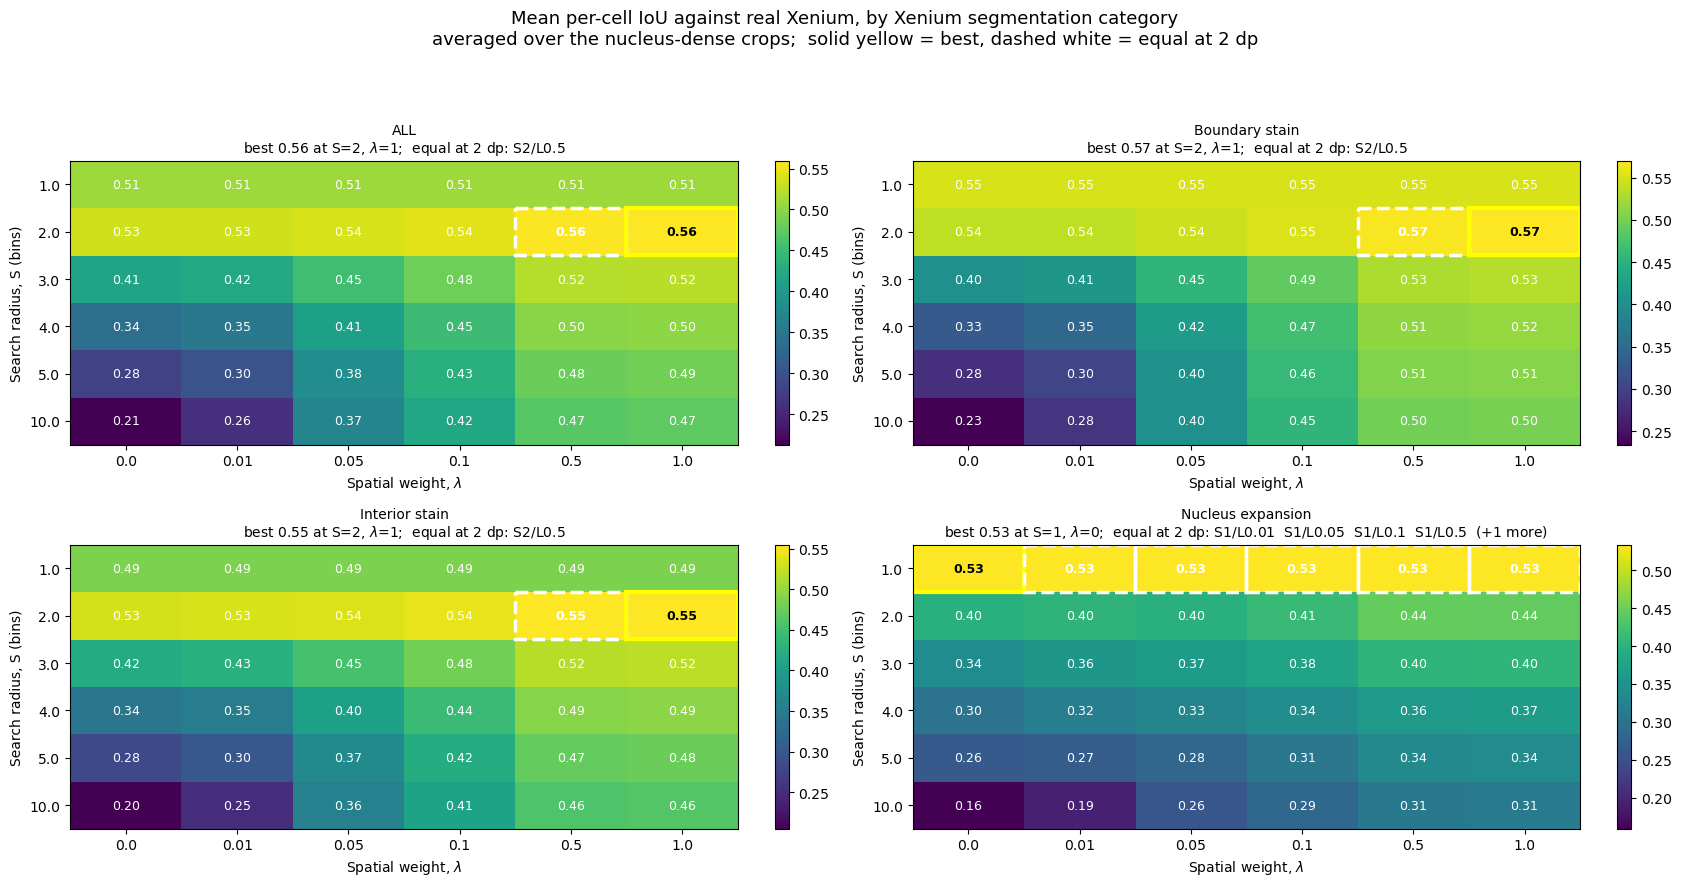

In [7]:
def plot_iou_heatmaps(summary, cats=CATS, value="mean_iou", decimals=2,
                      out_png=None, figsize=(17, 9)):
    """One heatmap per category; solid yellow = best, dashed white = tied at `decimals`."""
    ncol = 2
    nrow = int(np.ceil(len(cats) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, squeeze=False)
    ties_all = []
    for ax, cat in zip(axes.ravel(), cats):
        piv = iou_grid(summary, cat, value)
        v = piv.values.astype(float)
        vr = np.round(v, decimals)
        best = np.unravel_index(np.nanargmax(v), v.shape)
        bestr = np.nanmax(vr)
        im = ax.imshow(v, cmap="viridis", aspect="auto")
        ties = []
        for i in range(v.shape[0]):
            for j in range(v.shape[1]):
                if not np.isfinite(v[i, j]):
                    continue
                is_best = (i, j) == best
                tied = vr[i, j] == bestr
                if is_best:
                    ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                           ec="yellow", lw=3))
                elif tied:
                    ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                           ec="white", lw=2.5, ls="--"))
                    ties.append("S%g/L%g" % (piv.index[i], piv.columns[j]))
                    ties_all.append(dict(category=cat, S=piv.index[i], L=piv.columns[j],
                                         value=v[i, j]))
                ax.text(j, i, ("%." + str(decimals) + "f") % vr[i, j],
                        ha="center", va="center", fontsize=9,
                        color="black" if is_best else "white",
                        fontweight="bold" if tied else "normal")
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
        ax.set_xlabel("Spatial weight, $\\lambda$")
        ax.set_ylabel("Search radius, S (bins)")
        tt = "  ".join(ties) if ties else "none"
        if len(ties) > 4:
            tt = "  ".join(ties[:4]) + "  (+%d more)" % (len(ties) - 4)
        ax.set_title("%s\nbest %.2f at S=%g, $\\lambda$=%g;  equal at %d dp: %s"
                     % (cat, np.nanmax(v), piv.index[best[0]], piv.columns[best[1]],
                        decimals, tt), fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046)
    for ax in axes.ravel()[len(cats):]:
        ax.axis("off")
    fig.suptitle("Mean per-cell IoU against real Xenium, by Xenium segmentation category\n"
                 "averaged over the nucleus-dense crops;  solid yellow = best, "
                 "dashed white = equal at 2 dp", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    if out_png:
        fig.savefig(out_png, dpi=200, bbox_inches="tight", facecolor="white")
        print("[Log]: saved", out_png)
    return fig, pd.DataFrame(ties_all)

fig, ties = plot_iou_heatmaps(
    iou_run_summary,
    out_png=os.path.join(OUT_DIR, "IOU_BY_CATEGORY_WITH_TIES_2dp.png"),
)
ties.to_csv(os.path.join(OUT_DIR, "iou_ties_2dp.csv"), index=False)
plt.show()


## Caveats

**Xenium is a reference, not ground truth.** Its boundaries are themselves inferred, and
the 5 um nucleus-expansion category is a fixed disc drawn where no stain resolved a
boundary. It disagrees with every reconstruction, which is exactly why the categories are
kept separate instead of pooled into one score.

**Mean against median.** Mean IoU is pulled down by poorly matched cells, median is not,
and they can favour different settings. Both are in `iou_summary_per_run.csv`; pass
`value="median_iou"` to `plot_iou_heatmaps` to see the median grid. The detection
precision / recall / F1 columns are there too, and are worth a look when a setting earns a
high mean IoU on very few matches.
